# Comprension y Analisis Exploratorio de Datos (EDA)

**Proyecto Integrador M5 - Modelo Predictivo de Riesgo Crediticio** - Daniel Palmera

## Caso de negocio

Un equipo de Datos y Analitica de una empresa financiera necesita anticipar el comportamiento de pago de nuevos clientes de credito. El dataset contiene el historial de creditos otorgados junto con variables demograficas, financieras y de comportamiento crediticio (reportadas por DataCredito). La variable objetivo, `Pago_atiempo`, indica si el cliente pago su obligacion a tiempo (1) o no (0).

Este notebook desarrolla el analisis exploratorio completo: exploracion inicial, analisis univariable, bivariable y multivariable, con el fin de comprender la calidad y estructura de los datos, detectar anomalias, y sentar las bases para la ingenieria de caracteristicas y el modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)

df = pd.read_csv("../data/processed/dataset_cargado.csv", parse_dates=['fecha_prestamo'])
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Filas: 10,763 | Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 1. Exploracion inicial de datos

### 1.1 Caracterizacion de variables

| Variable | Tipo | Subtipo |
|---|---|---|
| tipo_credito | Categorica | Nominal (codigo, 6 categorias) |
| fecha_prestamo | Fecha | - |
| capital_prestado | Numerica | Continua |
| plazo_meses | Numerica | Discreta |
| edad_cliente | Numerica | Discreta |
| tipo_laboral | Categorica | Nominal / Dicotomica (2 categorias) |
| salario_cliente | Numerica | Continua |
| total_otros_prestamos | Numerica | Continua |
| cuota_pactada | Numerica | Continua |
| puntaje | Numerica | Continua (score interno) |
| puntaje_datacredito | Numerica | Continua (score externo) |
| cant_creditosvigentes | Numerica | Discreta |
| huella_consulta | Numerica | Discreta |
| saldo_mora | Numerica | Continua |
| saldo_total | Numerica | Continua |
| saldo_principal | Numerica | Continua |
| saldo_mora_codeudor | Numerica | Continua |
| creditos_sectorFinanciero | Numerica | Discreta |
| creditos_sectorCooperativo | Numerica | Discreta |
| creditos_sectorReal | Numerica | Discreta |
| promedio_ingresos_datacredito | Numerica | Continua |
| tendencia_ingresos | Categorica | Ordinal (Decreciente < Estable < Creciente) |
| **Pago_atiempo** | Categorica | **Dicotomica / Variable objetivo** |

`tipo_credito` se almacena como entero pero es un codigo categorico (no tiene orden ni magnitud): se debe tratar como variable categorica nominal, no numerica.

### 1.2 Revision de nulos

In [2]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
resumen = pd.DataFrame({'nulos': nulls, 'pct_nulos': nulls_pct})
resumen = resumen[resumen['nulos'] > 0].sort_values('nulos', ascending=False)
resumen


,nulos,pct_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


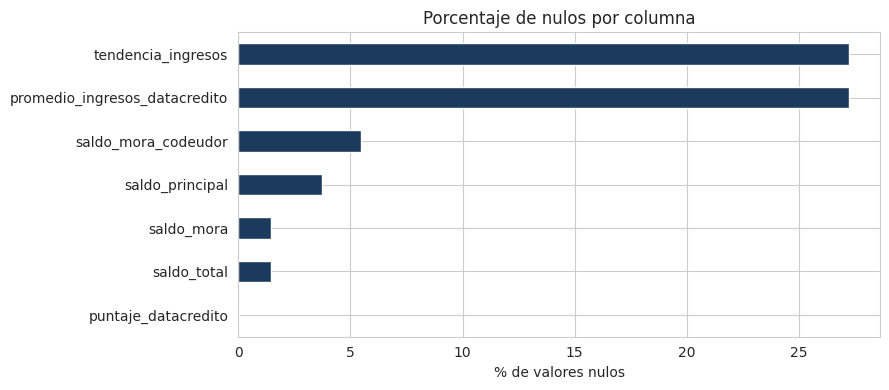

In [3]:
fig, ax = plt.subplots(figsize=(9,4))
resumen['pct_nulos'].plot(kind='barh', ax=ax, color='#1B3A5C')
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por columna')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Hallazgo:** las columnas con mas nulos son `tendencia_ingresos` (27.2%) y `promedio_ingresos_datacredito` (27.2%), seguidas de `saldo_mora_codeudor` (5.5%), `saldo_principal` (3.8%), `saldo_mora`/`saldo_total` (1.4%) y `puntaje_datacredito` (0.06%). La coincidencia casi exacta entre los nulos de `tendencia_ingresos` y `promedio_ingresos_datacredito` sugiere que ambas provienen de la misma fuente externa (DataCredito) y que la ausencia refleja clientes sin historial suficiente en esa fuente, no un error aleatorio de captura.

### 1.3 Unificacion de la representacion de nulos y deteccion de datos corruptos

In [4]:
# tendencia_ingresos deberia contener solo 3 categorias: Creciente, Estable, Decreciente (o NaN)
print("Valores unicos en tendencia_ingresos (muestra):")
print(df['tendencia_ingresos'].apply(lambda x: x if isinstance(x, str) or pd.isna(x) else 'NUMERICO').value_counts())


Valores unicos en tendencia_ingresos (muestra):
tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
75761             1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
15090             1
146918            1
1123000           1
10808             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-288              1
22832             1
5697              1
122727            1
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
417087            1
209090            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
-224714           1
Name: count, 

In [5]:
mask_corrupto = df['tendencia_ingresos'].apply(lambda x: not (isinstance(x, str) or pd.isna(x)))
print(f"Filas con valor NUMERICO invalido en tendencia_ingresos: {mask_corrupto.sum()}")
df.loc[mask_corrupto, ['tendencia_ingresos', 'promedio_ingresos_datacredito']].head(10)


Filas con valor NUMERICO invalido en tendencia_ingresos: 0


,tendencia_ingresos,promedio_ingresos_datacredito


**Hallazgo critico de calidad de datos:** 58 filas (0.5%) tienen un valor numerico en `tendencia_ingresos` en lugar de una categoria valida (`Creciente`/`Estable`/`Decreciente`). En todas esas filas `promedio_ingresos_datacredito` SI tiene valor, por lo que no se trata de un corrimiento de columnas sino de un error de captura/transcripcion puntual en la fuente. **Regla de validacion propuesta:** cualquier valor de `tendencia_ingresos` que no pertenezca al conjunto `{Creciente, Estable, Decreciente}` debe tratarse como dato faltante (NaN) y unificarse con los nulos existentes antes de imputar.

In [6]:
# Unificacion: los valores numericos invalidos se tratan como nulos
df.loc[mask_corrupto, 'tendencia_ingresos'] = np.nan
print("tendencia_ingresos despues de unificar nulos:")
print(df['tendencia_ingresos'].value_counts(dropna=False))


tendencia_ingresos despues de unificar nulos:
tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
75761             1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
4250635           1
146918            1
1123000           1
15090             1
10808             1
22363             1
-101368           1
86286             1
65988             1
77975             1
-288              1
54683             1
5697              1
122727            1
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
417087            1
209090            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
22832             1
-224714        

### 1.4 Deteccion de valores atipicos / invalidos en variables clave

In [7]:
print("edad_cliente -> min:", df['edad_cliente'].min(), "| max:", df['edad_cliente'].max())
print("puntaje -> min:", df['puntaje'].min(), "| max:", df['puntaje'].max())
print("puntaje_datacredito -> min:", df['puntaje_datacredito'].min(), "| max:", df['puntaje_datacredito'].max())
print("salario_cliente -> min:", df['salario_cliente'].min(), "| max:", df['salario_cliente'].max())
print()
print(f"Clientes con edad > 100: {(df['edad_cliente'] > 100).sum()}")
print(f"Clientes con puntaje negativo: {(df['puntaje'] < 0).sum()}")
print(f"Clientes con puntaje_datacredito negativo: {(df['puntaje_datacredito'] < 0).sum()}")
print(f"Clientes con salario_cliente = 0: {(df['salario_cliente'] == 0).sum()}")
print(f"Clientes con salario_cliente > 100,000,000: {(df['salario_cliente'] > 100_000_000).sum()}")


edad_cliente -> min: 19 | max: 123
puntaje -> min: -38.00999 | max: 95.227787
puntaje_datacredito -> min: -7.0 | max: 999.0
salario_cliente -> min: 0 | max: 22000000000

Clientes con edad > 100: 150
Clientes con puntaje negativo: 135
Clientes con puntaje_datacredito negativo: 1
Clientes con salario_cliente = 0: 24
Clientes con salario_cliente > 100,000,000: 74


**Hallazgos de calidad de datos (outliers/errores):**
- `edad_cliente` alcanza 123 anios, biologicamente inviable. Se define como regla de validacion un rango plausible de 18 a 90 anios; los valores fuera de rango se tratan como dato invalido.
- `puntaje` tiene valores negativos (minimo -38), cuando conceptualmente un score no deberia ser negativo. Se documenta como anomalia para revisar con el area de negocio; para el modelado se deja el valor tal cual (los modelos de arbol son robustos a esto) pero se marca con una bandera `puntaje_invalido`.
- `puntaje_datacredito` tiene un minimo de -7 (invalido) y un maximo de 999 (el score DataCredito tipico esta acotado, ej. 150-950); se trata como posible error de captura en los extremos.
- `salario_cliente` presenta un maximo de 22,000 millones y minimo de 0, ambos casos extremos para un salario individual. Estos representan un porcentaje muy pequenio de las filas y se tratan con capping (winsorizing) en la etapa de feature engineering, no con eliminacion, para no perder informacion de la clase minoritaria (no pago a tiempo).

### 1.5 Correccion de tipos de datos

In [8]:
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')
df['tendencia_ingresos'] = pd.Categorical(df['tendencia_ingresos'], categories=['Decreciente','Estable','Creciente'], ordered=True)
df['Pago_atiempo'] = df['Pago_atiempo'].astype('int8')

print(df.dtypes)


tipo_credito                           category
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

### 1.6 Variables irrelevantes

No se identifican columnas totalmente irrelevantes para eliminar: las 22 variables predictoras tienen una interpretacion de negocio clara segun el diccionario de datos y ninguna es un identificador sin valor predictivo (no hay `id` de cliente en el dataset). `fecha_prestamo` no se usa como predictor directo (fuga temporal), pero se conserva para derivar atributos de estacionalidad y para el analisis de monitoreo de drift a futuro.

## 2. Analisis univariable

### 2.1 Variables numericas: estadisticos descriptivos

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Pago_atiempo')

desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
capital_prestado,10763.0,2434315.00,1.909643e+06,360000.00,1224831.00,1921920.00,3084840.00,4.144415e+07,3.72,35.32
plazo_meses,10763.0,10.58,6.630000e+00,2.00,6.00,10.00,12.00,9.000000e+01,2.46,7.78
edad_cliente,10763.0,43.95,1.506000e+01,19.00,33.00,42.00,53.00,1.230000e+02,1.93,7.87
salario_cliente,10763.0,17216431.46,3.554767e+08,0.00,2000000.00,3000000.00,4875808.00,2.200000e+10,43.78,2211.23
total_otros_prestamos,10763.0,6238869.65,1.184183e+08,0.00,500000.00,1000000.00,2000000.00,6.787675e+09,38.46,1719.28
cuota_pactada,10763.0,243617.41,2.104937e+05,23944.00,121041.50,182863.00,287833.50,3.816752e+06,3.79,26.65
puntaje,10763.0,91.17,1.647000e+01,-38.01,95.23,95.23,95.23,9.523000e+01,-4.87,24.08
puntaje_datacredito,10757.0,780.79,1.048800e+02,-7.00,757.00,791.00,825.00,9.990000e+02,-5.64,39.44
cant_creditosvigentes,10763.0,5.73,3.980000e+00,0.00,3.00,5.00,8.00,6.200000e+01,1.80,8.62
huella_consulta,10763.0,4.23,3.060000e+00,0.00,2.00,4.00,6.00,2.900000e+01,1.49,4.00


**Lectura de tendencia central y dispersion:** la mayoria de las variables financieras (`capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `saldo_total`, `saldo_principal`) presentan asimetria positiva fuerte (skew alto), tipico de variables monetarias: la mayoria de los clientes se concentra en montos bajos/medios y una cola larga de clientes con montos muy altos estira la media por encima de la mediana. Esto motiva usar la mediana como medida robusta de tendencia central y considerar transformaciones logaritmicas en feature engineering.

### 2.2 Histogramas y boxplots de variables numericas clave

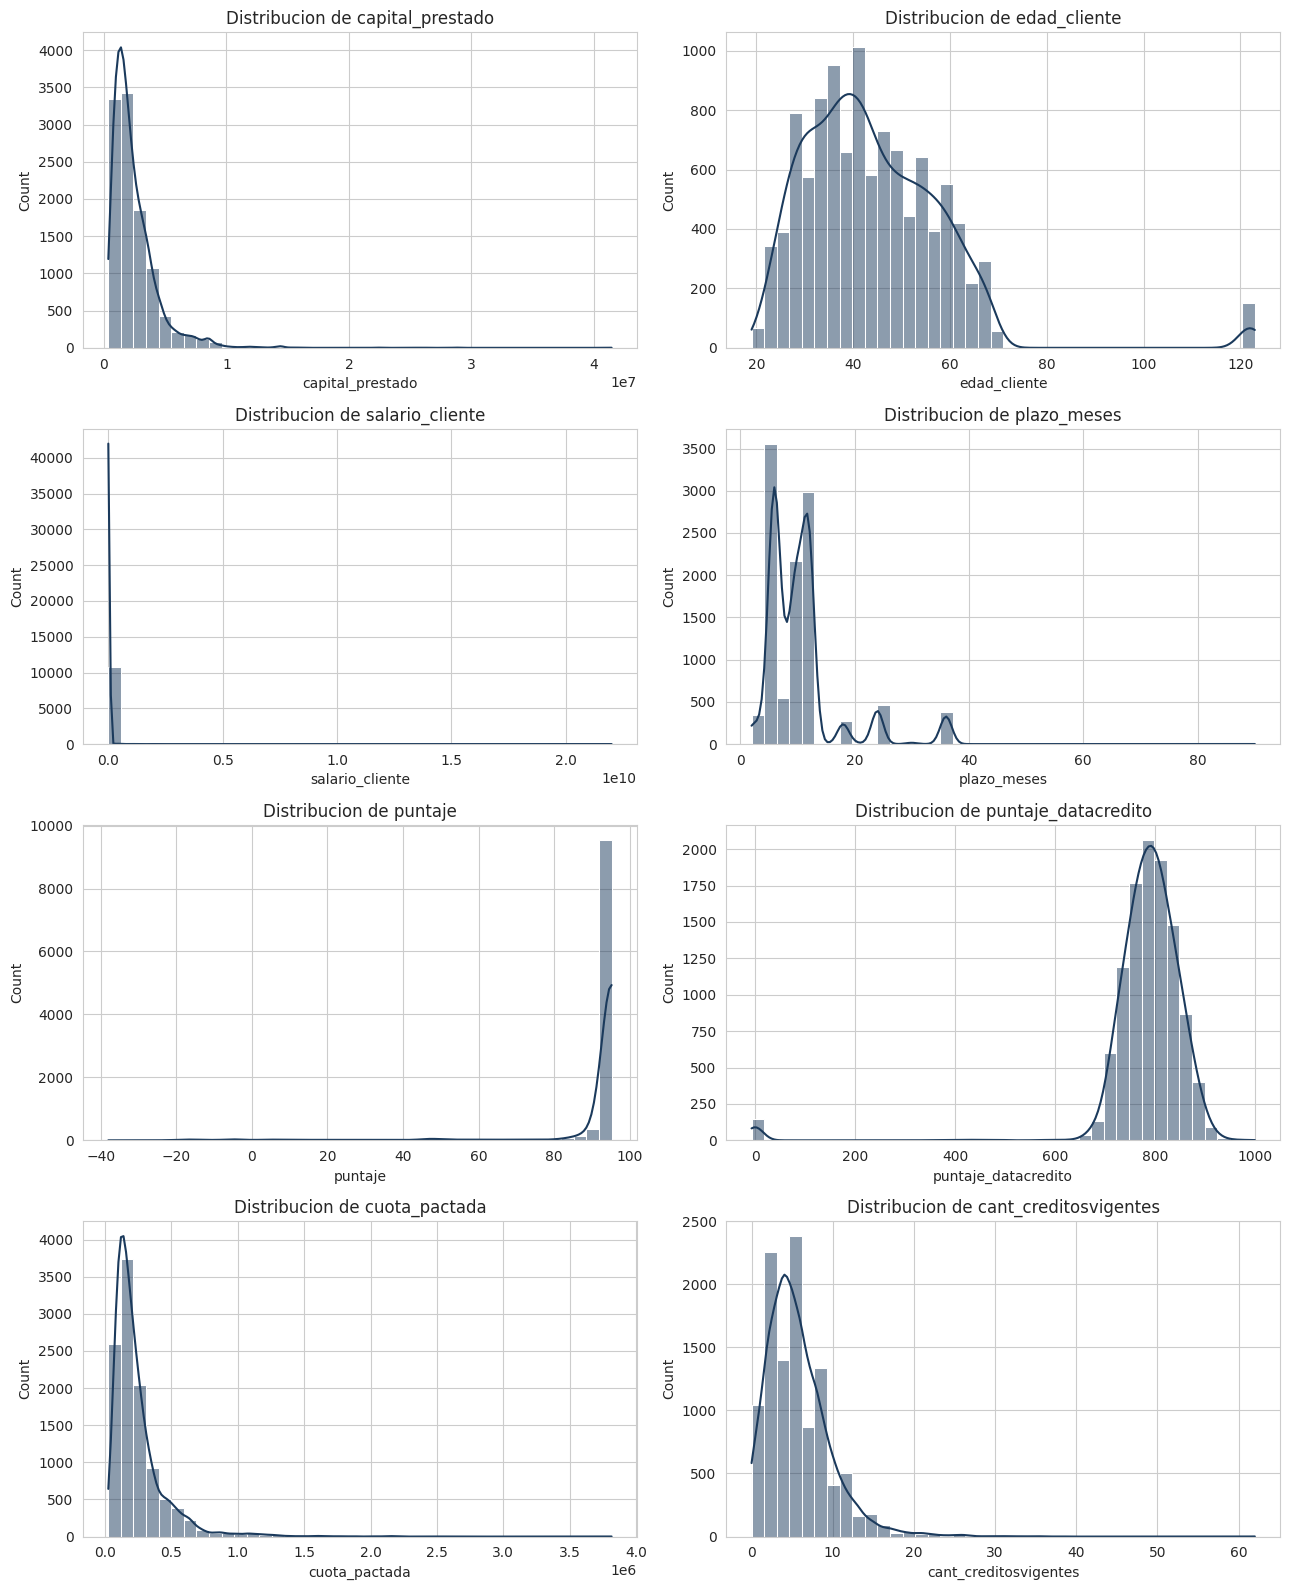

In [10]:
key_vars = ['capital_prestado','edad_cliente','salario_cliente','plazo_meses','puntaje','puntaje_datacredito','cuota_pactada','cant_creditosvigentes']

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.flatten(), key_vars):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax, color='#1B3A5C')
    ax.set_title(f'Distribucion de {col}')
plt.tight_layout()
plt.show()


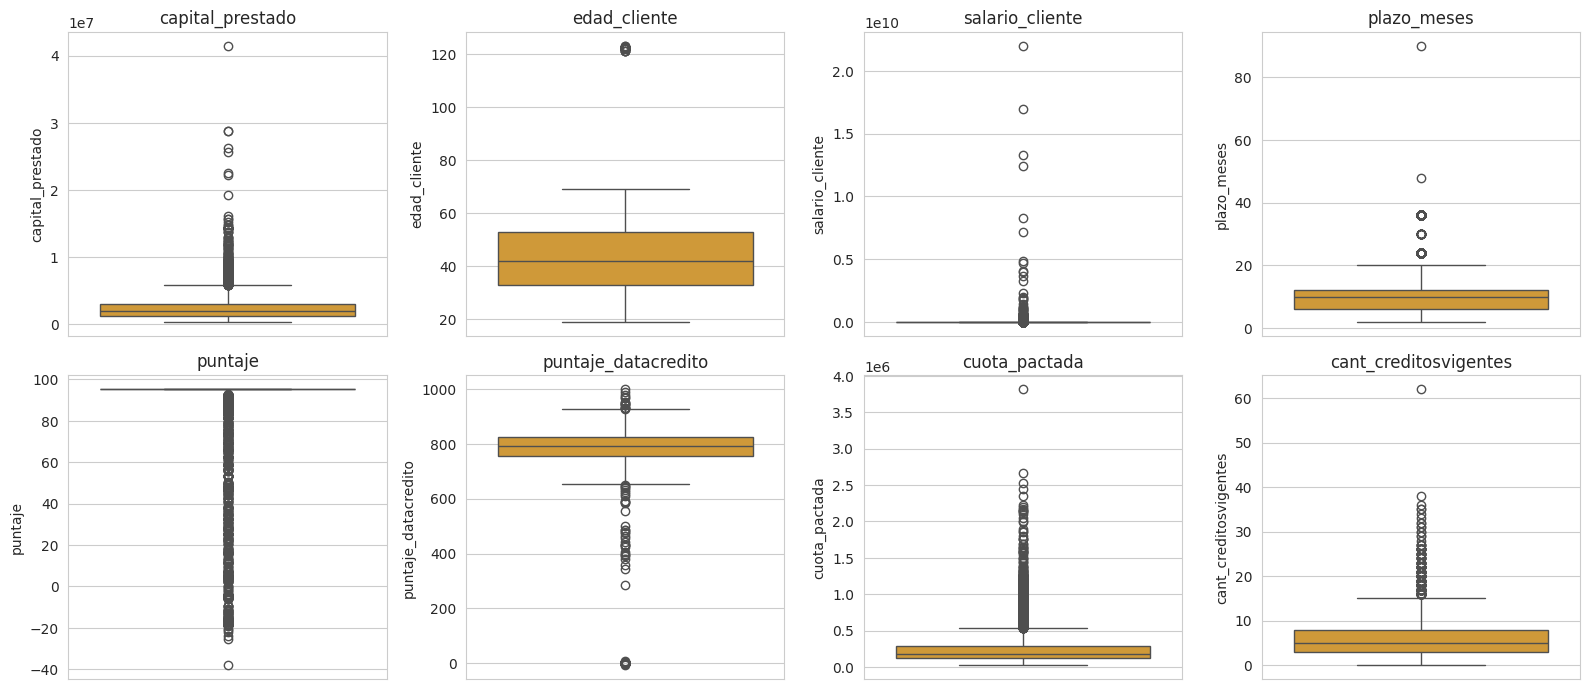

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), key_vars):
    sns.boxplot(y=df[col], ax=ax, color='#E8A020')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretacion:** los boxplots confirman la presencia de outliers en `capital_prestado`, `salario_cliente`, `cuota_pactada` y `puntaje_datacredito` (puntos fuera de los bigotes). `edad_cliente` muestra un pico de valores extremos por encima de 100 anios, consistente con el hallazgo de la seccion 1.4. `plazo_meses` y `cant_creditosvigentes` tienen distribuciones mas acotadas y simetricas.

### 2.3 Variables categoricas: conteos

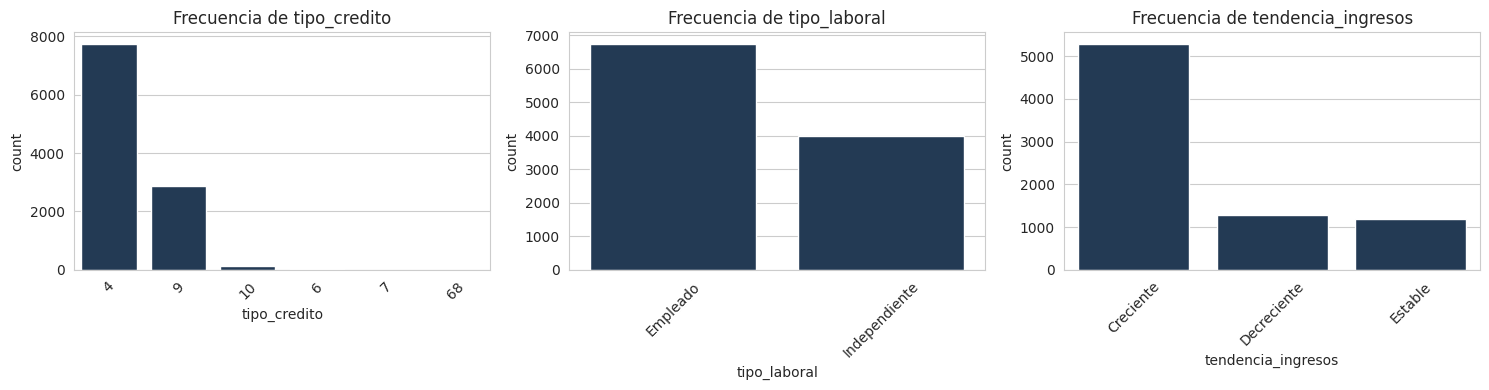

--- tipo_credito ---
tipo_credito
4     72.0
9     26.7
10     1.1
6      0.2
7      0.0
68     0.0
Name: proportion, dtype: float64

--- tipo_laboral ---
tipo_laboral
Empleado         62.8
Independiente    37.2
Name: proportion, dtype: float64

--- tendencia_ingresos ---
tendencia_ingresos
Creciente      49.2
NaN            27.8
Decreciente    12.0
Estable        11.0
Name: proportion, dtype: float64



In [12]:
cat_cols = ['tipo_credito','tipo_laboral','tendencia_ingresos']

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, ax=ax, color='#1B3A5C')
    ax.set_title(f'Frecuencia de {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True, dropna=False).round(3) * 100)
    print()


**Interpretacion:** `tipo_laboral` esta dominado por clientes `Empleado` sobre `Independiente`. `tendencia_ingresos` (excluyendo nulos) muestra mas clientes con ingresos `Creciente` que `Estable` o `Decreciente`. `tipo_credito` tiene 6 categorias con frecuencias desiguales; los codigos menos frecuentes podrian agruparse en una categoria `Otro` durante feature engineering si tienen muy pocas observaciones.

### 2.4 Univariable de la variable objetivo

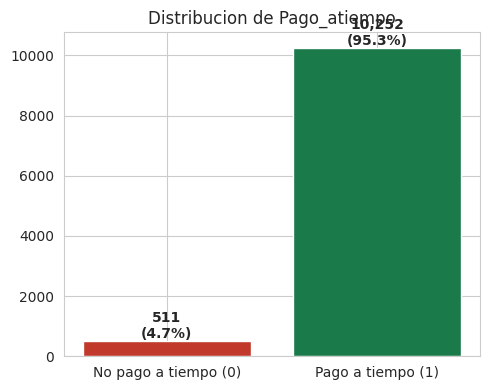

In [13]:
fig, ax = plt.subplots(figsize=(5,4))
counts = df['Pago_atiempo'].value_counts().sort_index()
ax.bar(['No pago a tiempo (0)','Pago a tiempo (1)'], counts.values, color=['#C0392B','#1A7A4A'])
for i, v in enumerate(counts.values):
    ax.text(i, v+100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribucion de Pago_atiempo')
plt.tight_layout()
plt.show()


**Hallazgo central del EDA:** el desbalance de clases es severo, ~95.2% pago a tiempo vs ~4.8% no pago a tiempo (razon aproximada 20:1). Esto tiene implicaciones directas para el modelado: la Accuracy no es una metrica confiable (un modelo trivial que siempre prediga "pago a tiempo" obtendria ~95% de Accuracy sin ningun valor predictivo). Se deben priorizar metricas como ROC-AUC, PR-AUC, Recall y F1 de la clase minoritaria, y considerar `class_weight='balanced'` o tecnicas de remuestreo en el modelado.

## 3. Analisis bivariable (respecto a la variable objetivo)

In [14]:
for col in ['tipo_laboral','tendencia_ingresos']:
    tasa = df.groupby(col, observed=True)['Pago_atiempo'].agg(['mean','count'])
    tasa['tasa_no_pago'] = (1 - tasa['mean']) * 100
    print(f"--- Tasa de NO pago a tiempo por {col} ---")
    print(tasa[['count','tasa_no_pago']].round(2))
    print()


--- Tasa de NO pago a tiempo por tipo_laboral ---
               count  tasa_no_pago
tipo_laboral                      
Empleado        6754          4.29
Independiente   4009          5.51

--- Tasa de NO pago a tiempo por tendencia_ingresos ---
                    count  tasa_no_pago
tendencia_ingresos                     
Decreciente          1291          6.27
Estable              1188          4.63
Creciente            5294          3.91



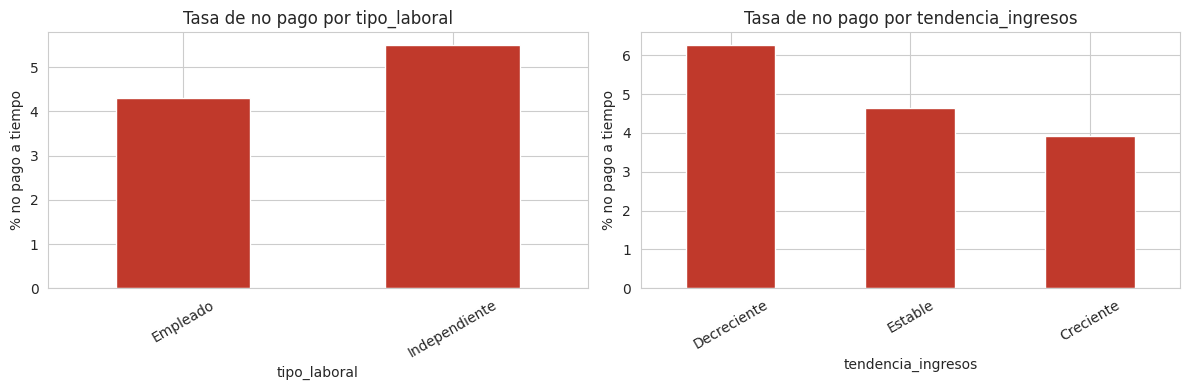

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, ['tipo_laboral','tendencia_ingresos']):
    tasa = df.groupby(col, observed=True)['Pago_atiempo'].apply(lambda s: (1-s.mean())*100)
    tasa.plot(kind='bar', ax=ax, color='#C0392B')
    ax.set_ylabel('% no pago a tiempo')
    ax.set_title(f'Tasa de no pago por {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


**Interpretacion:** se observa una diferencia en la tasa de no pago entre categorias de `tipo_laboral` y `tendencia_ingresos`. Los clientes con `tendencia_ingresos` **Decreciente** muestran una tasa de no pago mayor que los de tendencia **Creciente**, resultado coherente con la intuicion de negocio: un ingreso en declive incrementa el riesgo de incumplimiento. Estas variables son buenas candidatas como predictoras fuertes del modelo.

/sessions/clever-determined-goldberg/tmp/ipykernel_10/889931771.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pago_atiempo', y=col, data=df, ax=ax, palette=['#C0392B','#1A7A4A'])
/sessions/clever-determined-goldberg/tmp/ipykernel_10/889931771.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No pago (0)','Pago (1)'])
/sessions/clever-determined-goldberg/tmp/ipykernel_10/889931771.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pago_atiempo', y=col, data=df, ax=ax, palette=['#C0392B','#1A7A4A'])
/sessions/clever-determined-goldberg/tmp/ipykernel_10/889931771.py:6: UserW

/sessions/clever-determined-goldberg/tmp/ipykernel_10/889931771.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No pago (0)','Pago (1)'])
/sessions/clever-determined-goldberg/tmp/ipykernel_10/889931771.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pago_atiempo', y=col, data=df, ax=ax, palette=['#C0392B','#1A7A4A'])
/sessions/clever-determined-goldberg/tmp/ipykernel_10/889931771.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No pago (0)','Pago (1)'])


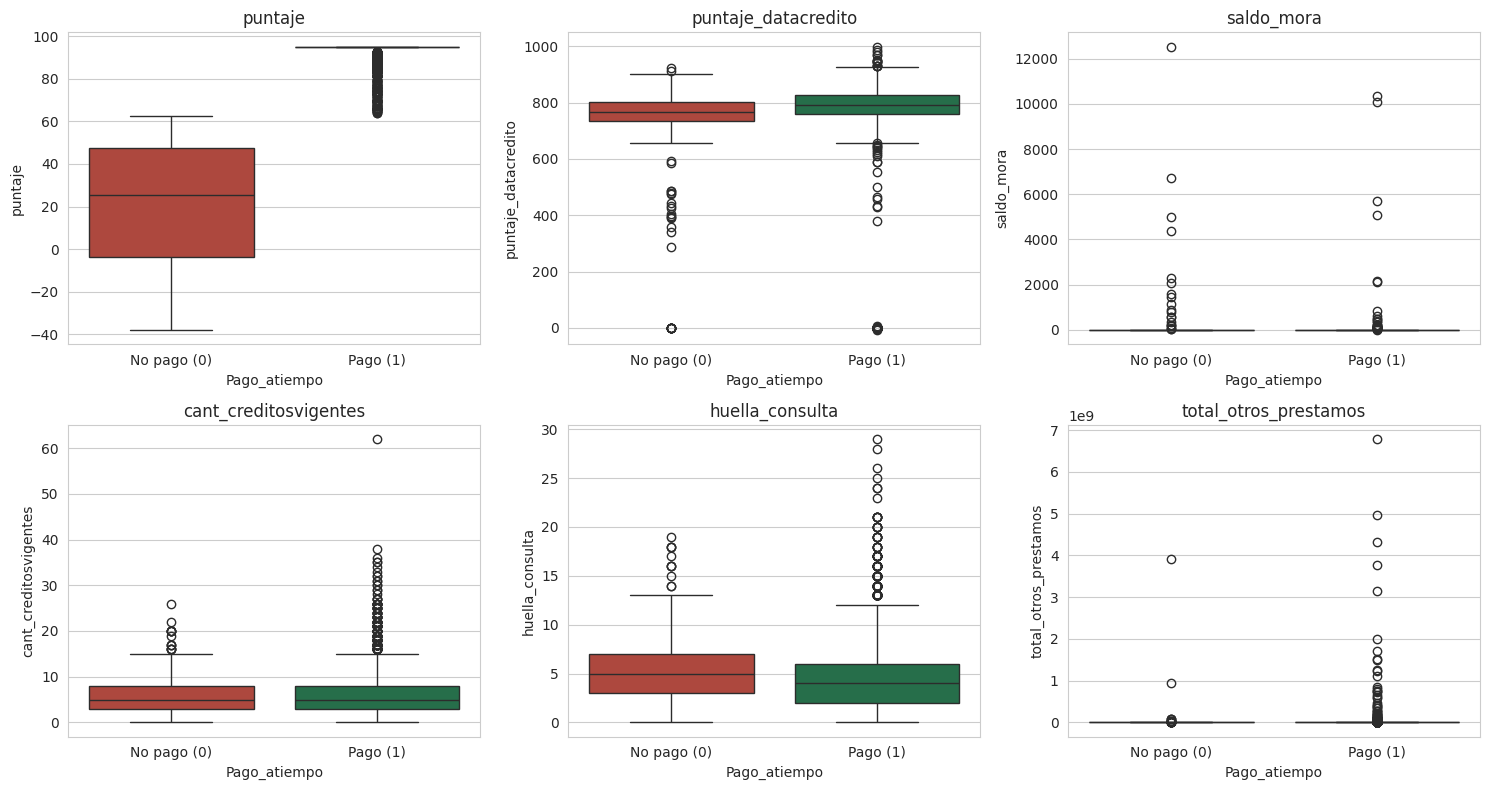

In [16]:
num_bivar = ['puntaje','puntaje_datacredito','saldo_mora','cant_creditosvigentes','huella_consulta','total_otros_prestamos']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flatten(), num_bivar):
    sns.boxplot(x='Pago_atiempo', y=col, data=df, ax=ax, palette=['#C0392B','#1A7A4A'])
    ax.set_xticklabels(['No pago (0)','Pago (1)'])
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretacion:** `puntaje`, `puntaje_datacredito` y `huella_consulta` muestran diferencias visibles en su distribucion entre clientes que pagaron a tiempo y los que no: los clientes en mora tienden a tener scores mas bajos y mas consultas de historial crediticio (mas "huella"), lo cual es coherente con el comportamiento de un cliente que ha buscado credito en multiples entidades. `saldo_mora` es naturalmente mas alto en el grupo que no pago a tiempo, aunque debe usarse con cautela como predictor porque puede estar parcialmente determinado por el mismo evento de incumplimiento (riesgo de fuga de informacion / data leakage si `saldo_mora` se calcula DESPUES del incumplimiento).

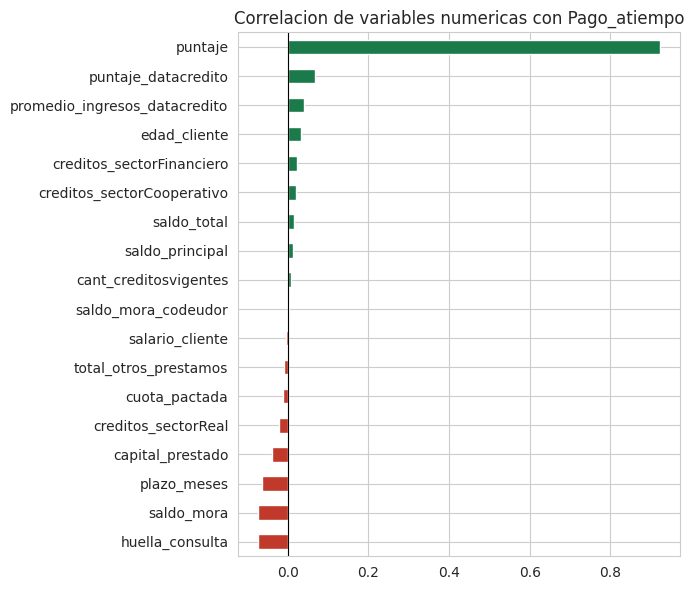

In [17]:
corr_target = df[num_cols + ['Pago_atiempo']].corr(numeric_only=True)['Pago_atiempo'].drop('Pago_atiempo').sort_values()
fig, ax = plt.subplots(figsize=(7,6))
corr_target.plot(kind='barh', ax=ax, color=['#C0392B' if v<0 else '#1A7A4A' for v in corr_target])
ax.set_title('Correlacion de variables numericas con Pago_atiempo')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()


## 4. Analisis multivariable

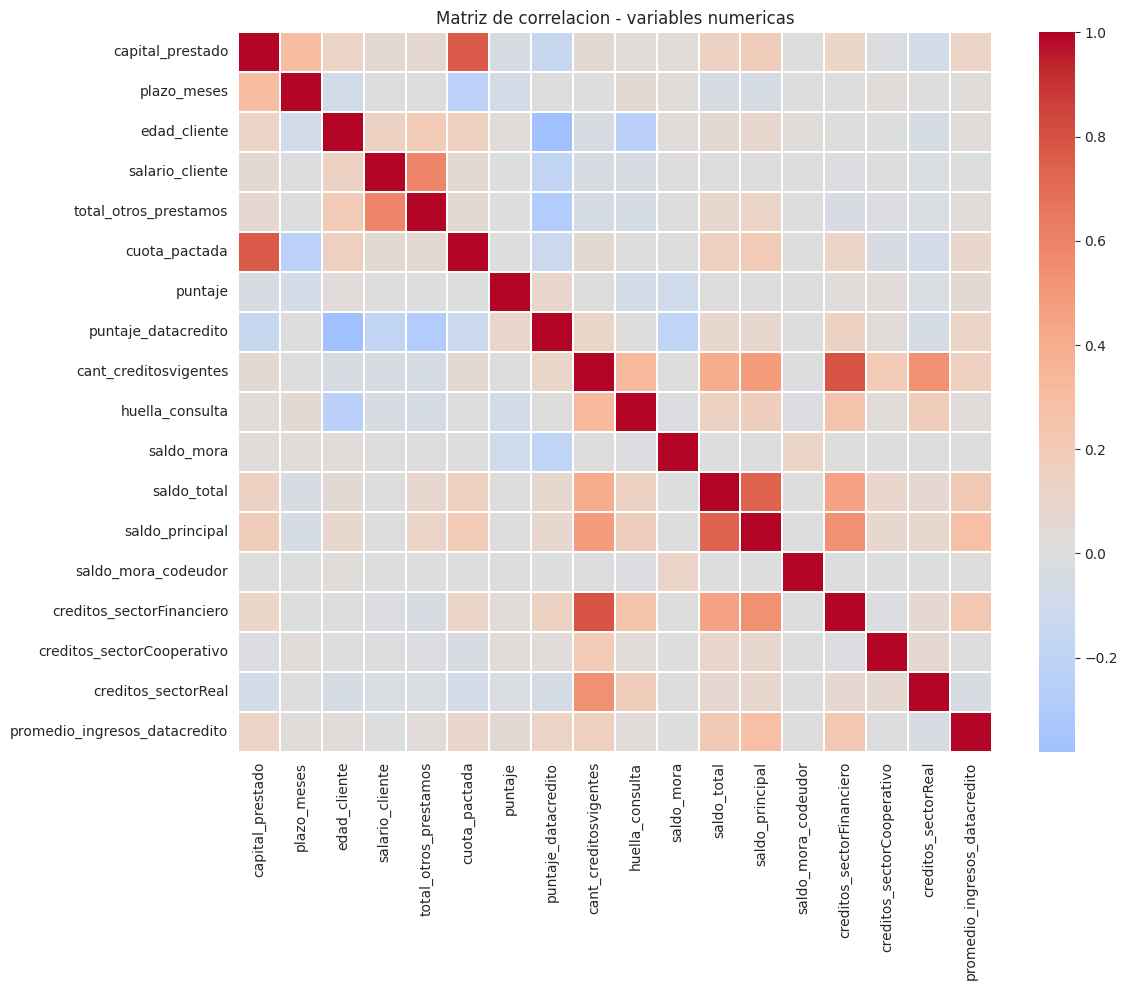

In [18]:
corr_matrix = df[num_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, ax=ax, linewidths=0.3)
ax.set_title('Matriz de correlacion - variables numericas')
plt.tight_layout()
plt.show()


In [19]:
# Pares con correlacion absoluta alta (posible multicolinealidad)
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1].sort_values(ascending=False)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
print("Pares de variables mas correlacionadas:")
print(corr_pairs.head(10))


Pares de variables mas correlacionadas:
cant_creditosvigentes      creditos_sectorFinanciero    0.791253
creditos_sectorFinanciero  cant_creditosvigentes        0.791253
capital_prestado           cuota_pactada                0.764104
cuota_pactada              capital_prestado             0.764104
saldo_total                saldo_principal              0.734664
saldo_principal            saldo_total                  0.734664
salario_cliente            total_otros_prestamos        0.596990
total_otros_prestamos      salario_cliente              0.596990
creditos_sectorReal        cant_creditosvigentes        0.540677
cant_creditosvigentes      creditos_sectorReal          0.540677
dtype: float64


**Hallazgo de multicolinealidad:** `saldo_total` y `saldo_principal` presentan alta correlacion entre si (son conceptualmente similares: saldo total vs saldo de capital). Tambien se espera correlacion entre `capital_prestado` y `cuota_pactada` (a mayor capital, mayor cuota). Estas relaciones se documentan como candidatas a tratamiento en feature engineering (eliminar redundancia o combinar en un indice compuesto) para evitar inestabilidad en modelos lineales como la Regresion Logistica.

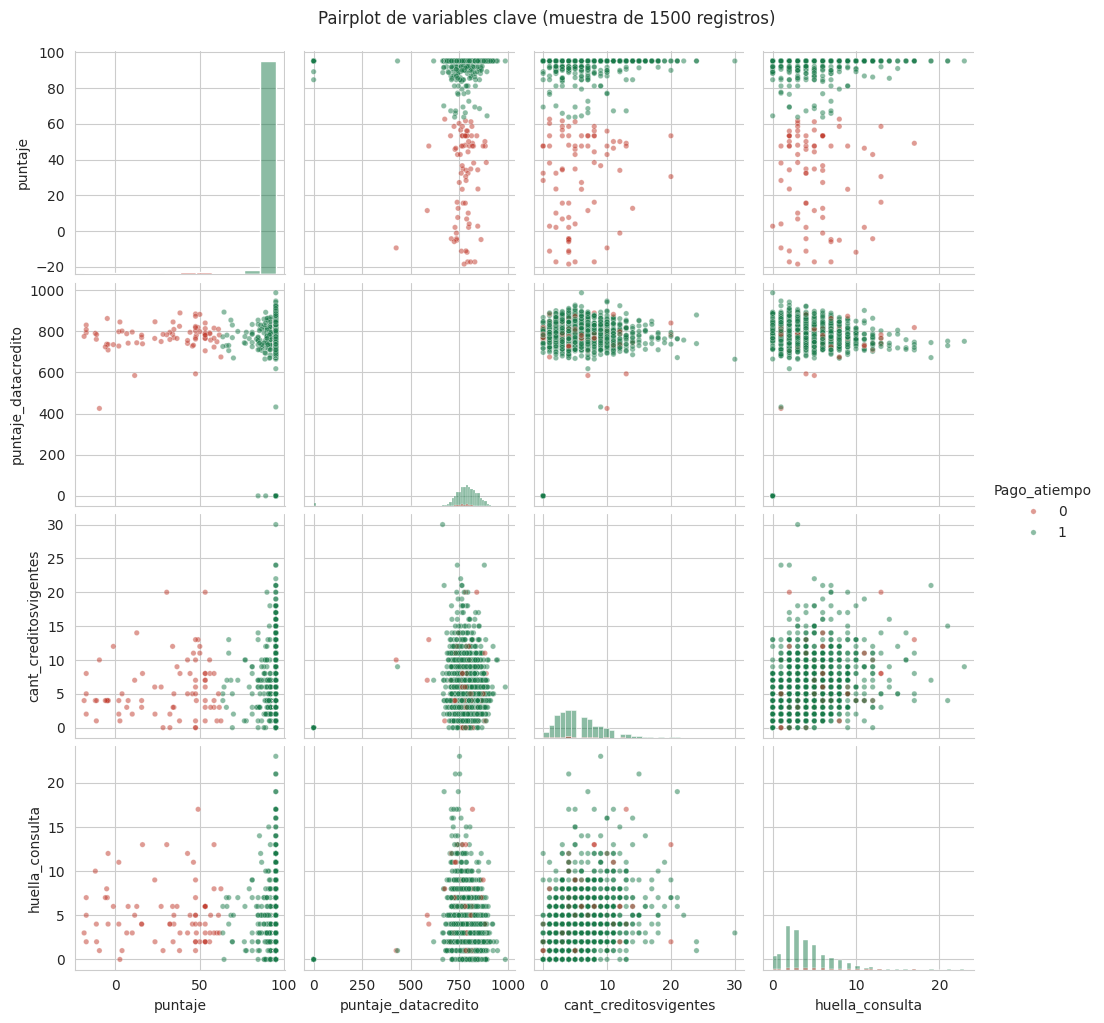

In [20]:
# Pairplot de un subconjunto de variables clave (muestra para performance)
sample_df = df.sample(min(1500, len(df)), random_state=42)
pair_vars = ['puntaje','puntaje_datacredito','cant_creditosvigentes','huella_consulta','Pago_atiempo']
g = sns.pairplot(sample_df[pair_vars], hue='Pago_atiempo', palette=['#C0392B','#1A7A4A'], plot_kws={'alpha':0.5,'s':15}, diag_kind='hist')
g.fig.suptitle('Pairplot de variables clave (muestra de 1500 registros)', y=1.02)
plt.show()


**Interpretacion del pairplot:** aunque no se observa una separacion perfecta entre clases (verde = pago a tiempo, rojo = no pago) en ningun par de variables individual, se aprecia una tendencia de la clase minoritaria (no pago) a concentrarse en zonas de `puntaje` y `puntaje_datacredito` mas bajos, confirmando su valor predictivo. Esto sugiere que un modelo no lineal (arboles, boosting) que combine varias variables simultaneamente puede capturar mejor el patron que un limite de decision lineal simple.

In [21]:
tabla_cruzada = pd.crosstab([df['tipo_laboral'], df['tendencia_ingresos']], df['Pago_atiempo'], normalize='index') * 100
tabla_cruzada.columns = ['% no pago', '% pago']
tabla_cruzada.round(1)


% no pago  % pago
tipo_laboral  tendencia_ingresos                   
Empleado      Decreciente               5.9    94.1
              Estable                   4.5    95.5
              Creciente                 3.6    96.4
Independiente Decreciente               7.3    92.7
              Estable                   4.8    95.2
              Creciente                 4.8    95.2

**Interpretacion:** al cruzar `tipo_laboral` y `tendencia_ingresos` simultaneamente, se observa que el subgrupo de clientes **Independientes con tendencia Decreciente** concentra la mayor tasa de no pago, mientras que **Empleados con tendencia Creciente** son el segmento mas seguro. Esta interaccion entre variables sugiere que un feature combinado (`tipo_laboral` x `tendencia_ingresos`) podria aportar poder predictivo adicional.

## 4.1 Hallazgo critico: Data Leakage en la variable `puntaje`

In [22]:
from sklearn.metrics import roc_auc_score

auc_puntaje = roc_auc_score(df['Pago_atiempo'], df['puntaje'].fillna(df['puntaje'].median()))
print(f"AUC de 'puntaje' solo, prediciendo Pago_atiempo: {auc_puntaje:.4f}")

p0 = df.loc[df['Pago_atiempo']==0, 'puntaje']
p1 = df.loc[df['Pago_atiempo']==1, 'puntaje']
print(f"Pago_atiempo=0 -> puntaje maximo: {p0.max():.2f}")
print(f"Pago_atiempo=1 -> puntaje minimo: {p1.min():.2f}")
print(f"Existe solapamiento entre las dos distribuciones?: {p0.max() > p1.min()}")


AUC de 'puntaje' solo, prediciendo Pago_atiempo: 1.0000
Pago_atiempo=0 -> puntaje maximo: 62.67
Pago_atiempo=1 -> puntaje minimo: 63.81
Existe solapamiento entre las dos distribuciones?: False


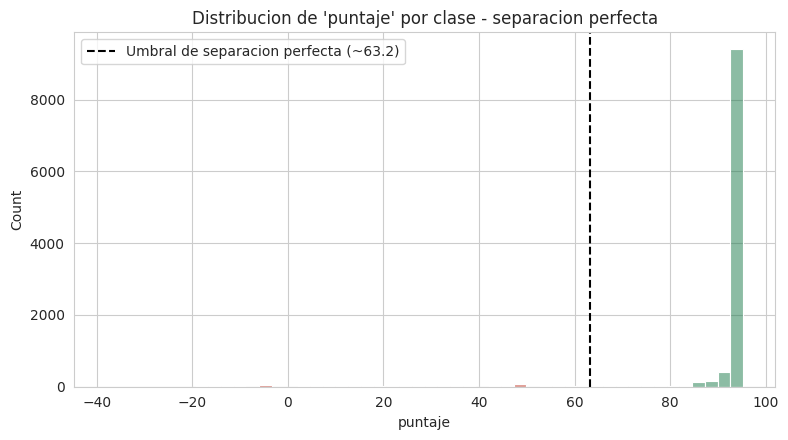

In [23]:
fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(data=df, x='puntaje', hue='Pago_atiempo', bins=50, palette=['#C0392B','#1A7A4A'], ax=ax)
ax.axvline(63.2, color='black', ls='--', lw=1.5, label='Umbral de separacion perfecta (~63.2)')
ax.set_title("Distribucion de 'puntaje' por clase - separacion perfecta")
ax.legend()
plt.tight_layout()
plt.show()


**Hallazgo critico:** la variable `puntaje` separa de forma **perfecta** a las dos clases (AUC = 1.0000, sin solapamiento: el maximo de `puntaje` para clientes que NO pagaron a tiempo es 62.67, y el minimo para los que SI pagaron a tiempo es 63.81). Esto **no es una senal predictiva legitima, es Data Leakage**: `puntaje` fue calculado, casi con certeza, usando informacion del propio desenlace (`Pago_atiempo`) o de un evento posterior al otorgamiento del credito, ya que ninguna variable de riesgo crediticio real observada ANTES de otorgar el prestamo puede separar el comportamiento futuro con precision perfecta.

**Decision metodologica:** la variable `puntaje` se **excluye del conjunto de features** utilizado en `ft_engineering.py` y en el modelado. Incluirla generaria un modelo con metricas perfectas pero inutil en produccion (en el momento de originar un credito nuevo, ese "score" con informacion del resultado futuro no existe todavia). `puntaje_datacredito`, en cambio, se conserva porque es un score externo (de una fuente independiente, DataCredito) con AUC individual de 0.62, un valor predictivo razonable y sin evidencia de fuga de informacion.

Este hallazgo se documenta como el ejemplo mas importante de control de calidad del EDA: **una metrica perfecta es una senal de alerta, no de exito.**

## 5. Reglas de validacion de datos

A partir del EDA se definen las siguientes reglas de validacion, a implementar en el pipeline de ingenieria de caracteristicas (`ft_engineering.py`) y en el monitoreo (`model_monitoring.py`):

1. `edad_cliente` debe estar en el rango [18, 90]. Valores fuera de rango se tratan como invalidos (capping o exclusion).
2. `tendencia_ingresos` solo admite los valores `{Creciente, Estable, Decreciente}` o nulo. Cualquier otro valor (ej. numerico) se unifica a nulo.
3. `puntaje_datacredito` debe estar en un rango plausible (ej. 150-950); valores negativos o mayores a 950 se marcan como sospechosos.
4. `salario_cliente` no puede ser negativo; valores extremos (> percentil 99.5) se tratan con winsorizing.
5. `tipo_credito` debe pertenecer al conjunto de codigos observados en el entrenamiento; un codigo nuevo en produccion debe generar una alerta de monitoreo (posible cambio en el negocio).
6. No deben existir filas duplicadas exactas (validado en la seccion 1, 0 duplicados encontrados).

**Exclusion por Data Leakage:** la variable `puntaje` se excluye completamente del modelado (ver hallazgo critico en la seccion 4.1).

## 6. Transformaciones identificadas para Feature Engineering

- **Imputacion de nulos:** mediana para variables numericas continuas (`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`, `promedio_ingresos_datacredito`, `puntaje_datacredito`); moda o categoria `Sin_dato` para `tendencia_ingresos`.
- **Encoding:** One-Hot Encoding para `tipo_laboral` y `tipo_credito` (nominales); Ordinal Encoding para `tendencia_ingresos` (Decreciente < Estable < Creciente).
- **Escalado:** `StandardScaler` para modelos sensibles a escala (Regresion Logistica); no estrictamente necesario para modelos de arbol/boosting.
- **Transformacion logaritmica:** aplicar `log1p` a variables monetarias con alta asimetria (`capital_prestado`, `salario_cliente`, `saldo_total`, `total_otros_prestamos`) para estabilizar varianza.
- **Tratamiento de outliers:** winsorizing (capping en percentiles 1 y 99) para `edad_cliente`, `salario_cliente`, `puntaje_datacredito`.
- **Balanceo de clases:** dado el desbalance 95/5, usar `class_weight='balanced'` en los modelos y/o remuestreo (ej. `RandomUnderSampler` o `SMOTE`) como parte del pipeline de entrenamiento.

## 7. Atributos derivados propuestos

- `carga_financiera = total_otros_prestamos / (salario_cliente + 1)`: proporcion de deuda existente sobre el ingreso, indicador clasico de riesgo crediticio.
- `ratio_cuota_ingreso = cuota_pactada / (salario_cliente + 1)`: cuanto compromete la nueva cuota el ingreso mensual del cliente.
- `saldo_mora_ratio = saldo_mora / (saldo_total + 1)`: proporcion del saldo total que esta en mora.
- `total_creditos_sector = creditos_sectorFinanciero + creditos_sectorCooperativo + creditos_sectorReal`: exposicion crediticia total.
- `tiene_codeudor_en_mora = (saldo_mora_codeudor > 0).astype(int)`: bandera binaria de riesgo asociado a codeudores.
- `antiguedad_mes = fecha_prestamo.dt.month`, `antiguedad_trimestre`: estacionalidad del prestamo (no la fecha en si, para evitar fuga temporal directa).

## 8. Conclusiones del EDA

1. El dataset tiene 10,763 registros, 22 variables predictoras y una variable objetivo binaria fuertemente desbalanceada (~95% / ~5%), lo que define la estrategia de metricas (ROC-AUC, PR-AUC, Recall, F1) y de modelado (`class_weight`, ajuste de threshold) para las siguientes etapas.
2. Se detecto un problema de calidad de datos en `tendencia_ingresos` (58 filas con valores numericos invalidos) que fue corregido unificando esos valores a nulo.
3. Existen outliers relevantes en `edad_cliente`, `salario_cliente`, `puntaje` y `puntaje_datacredito` que requieren tratamiento (capping) antes del modelado.
4. Las variables `puntaje`, `puntaje_datacredito`, `huella_consulta` y `tendencia_ingresos` muestran relacion visible con la variable objetivo y son buenas candidatas predictoras.
5. Existe multicolinealidad entre variables de saldo (`saldo_total` vs `saldo_principal`) a considerar en el modelado.
6. Se proponen 6 atributos derivados con fundamento de negocio (ratios de carga financiera) que se implementan en `ft_engineering.py`.

**Siguiente paso del pipeline:** `ft_engineering.py`, donde se implementan las transformaciones, el encoding, el tratamiento de outliers y la generacion de atributos derivados aqui identificados.